In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

# Thiết kế giao diện biểu đồ
sns.set(style="whitegrid")

C:\Users\HP\AppData\Local\Temp\ipykernel_21876\833224121.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')


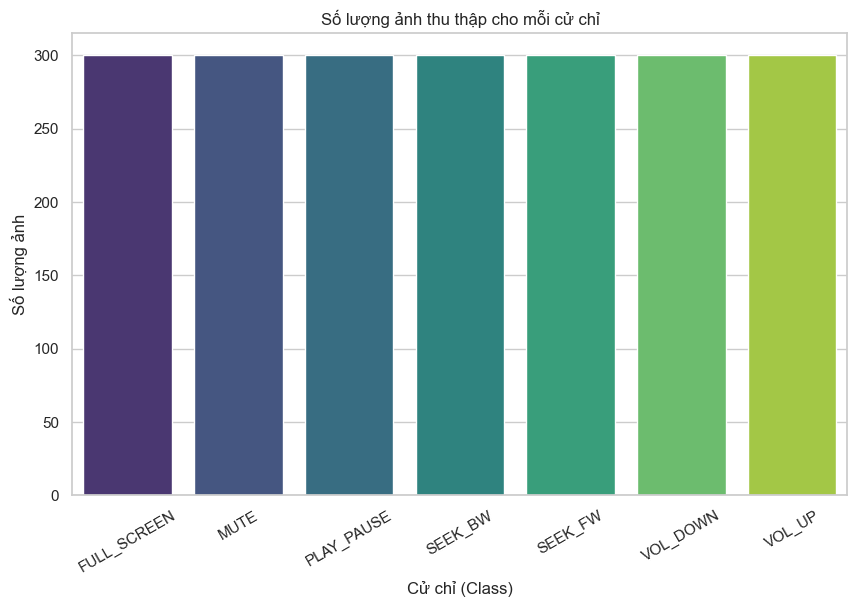

Thống kê chi tiết: {'FULL_SCREEN': 300, 'MUTE': 300, 'PLAY_PAUSE': 300, 'SEEK_BW': 300, 'SEEK_FW': 300, 'VOL_DOWN': 300, 'VOL_UP': 300}


In [4]:
dataset_path = '../data/DATASET'

classes = [d for d in os.listdir(dataset_path) if not d.startswith('.')]

valid_ext = ('.png', '.jpg', '.jpeg')

counts = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(valid_ext)]
    counts[cls] = len(files)

# sort
counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')
plt.title('Số lượng ảnh thu thập cho mỗi cử chỉ')
plt.xlabel('Cử chỉ (Class)')
plt.ylabel('Số lượng ảnh')
plt.xticks(rotation=30)
plt.show()

print("Thống kê chi tiết:", counts)

Tổng số dòng: 2075
------------------------------
Null theo từng cột:
0        0
1        0
2        0
3        0
4        0
5        0
6        0
7        0
8        0
9        0
10       0
11       0
12       0
13       0
14       0
15       0
16       0
17       0
18       0
19       0
20       0
21       0
22       0
23       0
24       0
25       0
26       0
27       0
28       0
29       0
30       0
31       0
32       0
33       0
34       0
35       0
36       0
37       0
38       0
39       0
40       0
41       0
42       0
43       0
44       0
45       0
46       0
47       0
48       0
49       0
50       0
51       0
52       0
53       0
54       0
55       0
56       0
label    0
dtype: int64
Tổng null: 0
Dòng gần như toàn 0: 0
Số dòng trùng: 0

Số lượng mỗi class:
label
SEEK_BW        300
VOL_UP         300
MUTE           299
PLAY_PAUSE     299
FULL_SCREEN    298
VOL_DOWN       293
SEEK_FW        286
Name: count, dtype: int64

Tỷ lệ (%):
label
SEEK_BW        14.46
V

C:\Users\HP\AppData\Local\Temp\ipykernel_21876\1246675403.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='magma')


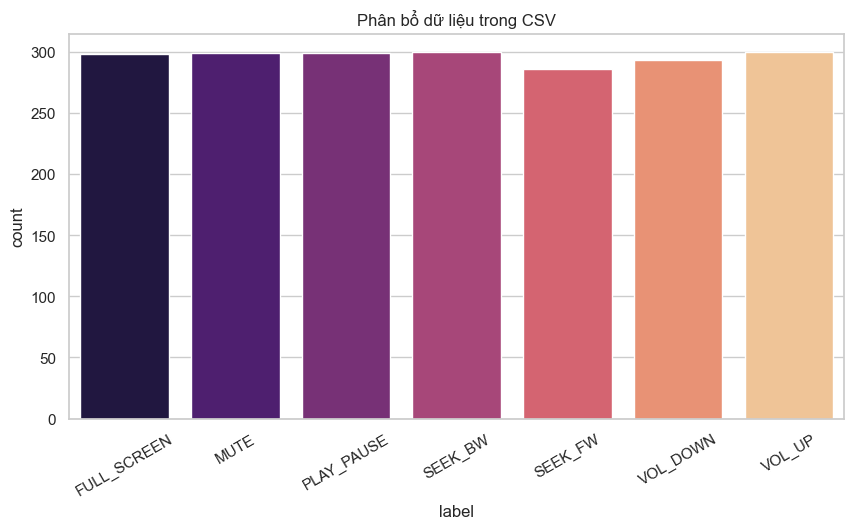

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dataset.csv')
df.rename(columns={df.columns[-1]: 'label'}, inplace=True)

print(f"Tổng số dòng: {len(df)}")
print("-" * 30)

# NULL
print("Null theo từng cột:")
print(df.isnull().sum())
print("Tổng null:", df.isnull().sum().sum())

# ZERO ROW
coords_only = df.iloc[:, :-1]
zero_rows = (coords_only.abs() < 1e-6).all(axis=1).sum()
print(f"Dòng gần như toàn 0: {zero_rows}")

#  DUPLICATE 
duplicates = df.duplicated().sum()
print("Số dòng trùng:", duplicates)

#  CLASS DISTRIBUTION 
counts = df['label'].value_counts()
print("\nSố lượng mỗi class:")
print(counts)

print("\nTỷ lệ (%):")
print((counts / len(df) * 100).round(2))

# PLOT 
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', palette='magma')
plt.title('Phân bổ dữ liệu trong CSV')
plt.xticks(rotation=30)
plt.show()

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/dataset.csv')

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

target_samples_per_class = 500
augmented_data = []

NUM_LANDMARK_FEATURES = 42 

for label in np.unique(y):
    class_indices = np.where(y == label)[0]
    class_X = X[class_indices]
    
    for row in class_X:
        augmented_data.append(list(row) + [label])
    
    current_count = len(class_X)
    
    while current_count < target_samples_per_class:
        base_row = class_X[np.random.randint(0, len(class_X))].copy()
        
        # TÁCH LANDMARK
        landmarks = base_row[:NUM_LANDMARK_FEATURES].copy()
        extra_features = base_row[NUM_LANDMARK_FEATURES:].copy()
    
        landmarks = landmarks.reshape(-1, 2)

        # FLIP 
        if np.random.rand() > 0.5:
            landmarks[:, 0] = 1.0 - landmarks[:, 0]

        # NOISE 
        noise = np.random.normal(0, 0.01, size=landmarks.shape)
        landmarks += noise

        # SCALE 
        center = landmarks[0]  
        scale = np.random.uniform(0.9, 1.1)
        landmarks = center + (landmarks - center) * scale

        # GHÉP LẠI 
        landmarks = landmarks.flatten()
        new_row = np.concatenate([landmarks, extra_features])

        augmented_data.append(list(new_row) + [label])
        current_count += 1


augmented_df = pd.DataFrame(augmented_data)
augmented_df.to_csv('../data/dataset.csv', index=False)

print("Augmentation done:", len(augmented_df))

Augmentation done: 3500


Tổng số dòng: 3500
------------------------------
Null theo từng cột:
0        0
1        0
2        0
3        0
4        0
5        0
6        0
7        0
8        0
9        0
10       0
11       0
12       0
13       0
14       0
15       0
16       0
17       0
18       0
19       0
20       0
21       0
22       0
23       0
24       0
25       0
26       0
27       0
28       0
29       0
30       0
31       0
32       0
33       0
34       0
35       0
36       0
37       0
38       0
39       0
40       0
41       0
42       0
43       0
44       0
45       0
46       0
47       0
48       0
49       0
50       0
51       0
52       0
53       0
54       0
55       0
56       0
label    0
dtype: int64
Tổng null: 0
Dòng gần như toàn 0: 0
Số dòng trùng: 0

Số lượng mỗi class:
label
FULL_SCREEN    500
MUTE           500
PLAY_PAUSE     500
SEEK_BW        500
SEEK_FW        500
VOL_DOWN       500
VOL_UP         500
Name: count, dtype: int64

Tỷ lệ (%):
label
FULL_SCREEN    14.29
M

C:\Users\HP\AppData\Local\Temp\ipykernel_21876\1246675403.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='magma')


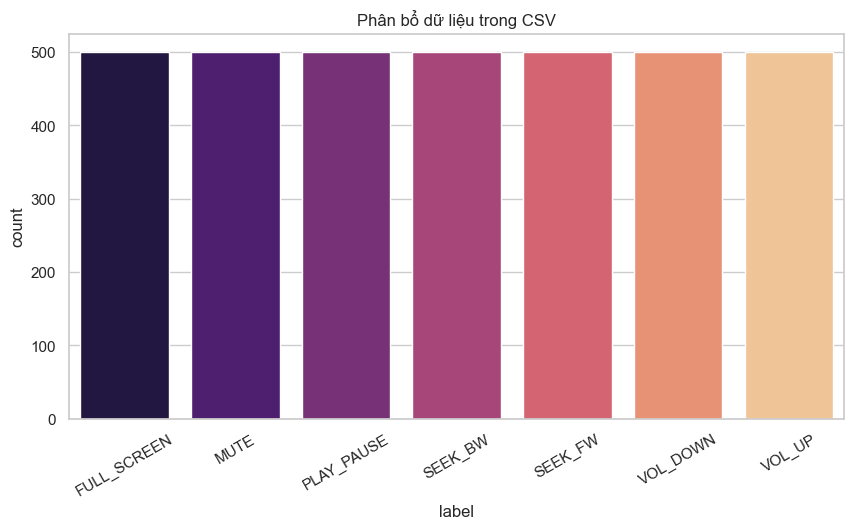

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dataset.csv')
df.rename(columns={df.columns[-1]: 'label'}, inplace=True)

print(f"Tổng số dòng: {len(df)}")
print("-" * 30)

# NULL
print("Null theo từng cột:")
print(df.isnull().sum())
print("Tổng null:", df.isnull().sum().sum())

# ZERO ROW
coords_only = df.iloc[:, :-1]
zero_rows = (coords_only.abs() < 1e-6).all(axis=1).sum()
print(f"Dòng gần như toàn 0: {zero_rows}")

#  DUPLICATE 
duplicates = df.duplicated().sum()
print("Số dòng trùng:", duplicates)

#  CLASS DISTRIBUTION 
counts = df['label'].value_counts()
print("\nSố lượng mỗi class:")
print(counts)

print("\nTỷ lệ (%):")
print((counts / len(df) * 100).round(2))

# PLOT 
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', palette='magma')
plt.title('Phân bổ dữ liệu trong CSV')
plt.xticks(rotation=30)
plt.show()

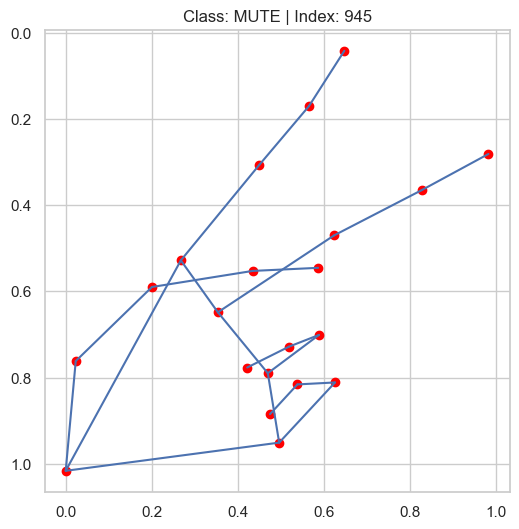

In [9]:
def plot_hand_skeleton(row_index):
    row = df.iloc[row_index, :-1].values
    label = df.iloc[row_index, -1]
    
    NUM_LANDMARK_FEATURES = 42  # 21 điểm * (x,y)
    
    coords = row[:NUM_LANDMARK_FEATURES]
    coords = coords.reshape(-1, 2)
    
    x_coords = coords[:, 0]
    y_coords = coords[:, 1]
    
    plt.figure(figsize=(6, 6))
    plt.scatter(x_coords, y_coords, c='red')
    
    connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),
        (0, 5), (5, 6), (6, 7), (7, 8),
        (5, 9), (9, 10), (10, 11), (11, 12),
        (9, 13), (13, 14), (14, 15), (15, 16),
        (13, 17), (17, 18), (18, 19), (19, 20), (0, 17)
    ]
    
    for start, end in connections:
        plt.plot([x_coords[start], x_coords[end]],
                 [y_coords[start], y_coords[end]], 'b-')
        
    plt.gca().invert_yaxis()
    plt.title(f"Class: {label} | Index: {row_index}")
    plt.show()


# Test
plot_hand_skeleton(random.randint(0, len(df)-1))